# <center>DecisionTreeClassifier</center>
<ul>
    <li>DecisionTreeClassifier: se trata de un Modelo de Aprendizaje Automático (supervisado): Utilizamos este enfoque para comprender o mostrar los tipos de datos de cada columna en un conjunto de datos.</li>
    <li>Cada nodo representa un punto de partida para tomar decisiones y, al mismo tiempo, se divide en 2 nodos hoja, donde cada nodo representa una decisión. El modelo de Árbol de Decisiones nos conducirá a una clasificación final.</li>
    <li>Evaluaremos el modelo mediante diversas bibliotecas que nos ayudarán a optimizarlo de la mejor manera posible y a obtener resultados precisos.</li>
    <li>Usaremos un conjunto de datos real con más de 2,000 registros.</li>
</ul>

# 1. Importamos las librerias a utilizar para nuestro modelo DecisionTreeClassifier
<ul>
   <li>sklearn.model_selection: Este es un módulo de la biblioteca de Python, Scikit-Learn (sklearn). Proporciona una serie de funciones que ayudan a trabajar con los datos de aprendizaje de diversas maneras, una de las cuales es la división de datos en conjuntos de entrenamiento (train_test_split) y pruebas. Además, ofrece funcionalidades para realizar validaciones cruzadas (cross_validate), entre otras tareas.</li>
</ul>

In [1]:
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, KFold,GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
# Librearias para el uso de graficas 
from pandas.plotting import scatter_matrix
from string import ascii_letters
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos y visualizamos nuestro dataSet utilizando pandas 
* El dataSet es obtenidos de> https://catalogue.ceh.ac.uk/documents/79669141-cde5-49f0-b24d-f3c6a1a52db8

In [2]:
data=pd.read_csv("data/dataSetpH.csv",encoding='latin-1')
data.head(2)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER
0,AZFZMV,JQWCHLFHEI,2007,4.31,93.98097,516.895335,78.471725,0.101209,86.396896,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0
1,AZFZMV,TBVIDVQSYN,2007,4.26,95.67244,526.198420,105.353200,0.133477,83.977858,NaN,NaN,NaN,31s,39,SCO,Shetland Islands,Intermediate uplands and Islands (Scotland),Fuertemenete Ácido,2.0


# 3. Realizamos un análisis de nuestros conjuntos de datos para identificar posibles datos faltantes o excedentes. 
### En este contexto, nos enfocaremos en las siguientes columnas
* PH: Valor del pH del suelo
* STATE_PH: Estado del pH del suelo (etiquetas)
* STATE_PH_INT: Estado del pH en valores numéricos"

In [3]:
data.isnull().sum()
# Tenemos datos nulos en las columans que utilizaremos para nuestro modelo de entrenamiento, en las columnas PH, STATE_PH, STATE_NUMBER. 
# Emplearemos estas columnas para entrenar nuestro modelo de predicción.    

SQUARE             0
PLOT               0
ANO                0
PH                 1
LOI               31
C_CONC_LOI        31
C_STOCK_LOI       75
BULK_DENSITY      75
MOISTURE          50
N_PERCENT       1641
N_STOCK         1655
PO4_OLSEN       1601
LC07               0
LC07_NUM           0
COUNTRY            0
COUNTY07           0
EZ_DESC_07         0
STATE_PH           1
STATE_NUMBER       1
dtype: int64

# 4. Eliminamos nuestros datos faltantes para que estén limpios y listos para su análisis
* Eiminamos los datos faltantes en la columnas de PH, STATE_PH, TATE_NUMBER

In [4]:
data.dropna(subset=["PH", "STATE_PH","STATE_NUMBER"], inplace=True)
data['STATE_PH_INT'] = data['STATE_NUMBER'].astype(int)

In [5]:
datos_asc = data.sort_values("PH", ascending=True)  # ordenamos nuestros datos de menor a mayor 
x_asc = datos_asc[["PH"]]
y_asc = datos_asc["STATE_PH_INT"]
datos_asc.head(5)

,SQUARE,PLOT,ANO,PH,LOI,C_CONC_LOI,C_STOCK_LOI,BULK_DENSITY,MOISTURE,N_PERCENT,N_STOCK,PO4_OLSEN,LC07,LC07_NUM,COUNTRY,COUNTY07,EZ_DESC_07,STATE_PH,STATE_NUMBER,STATE_PH_INT
304,HIZWNL,MIOUKRJLOG,2007,3.31,89.361920,491.490560,95.759693,0.129890,84.964290,NaN,NaN,NaN,19e,21,ENG,Northumberland,Uplands (England),Extremadamente Ácido,1.0,1
1070,KLOORS,GPVDGZNSYG,2007,3.32,7.527621,41.401916,56.058643,0.902674,34.730047,0.22,2.978824,3.0,6w,42,WAL,West Glamorgan,Lowlands (Wales),Extremadamente Ácido,1.0,1
1835,SSAXXL,DXBEDAGMKG,2007,3.33,95.947440,527.710920,68.550061,0.086601,80.334364,NaN,NaN,NaN,22s,30,SCO,Aberdeenshire,True uplands (Scotland),Extremadamente Ácido,1.0,1
2197,WKTPKP,JXIOUBSZMS,2007,3.37,44.575730,245.166515,110.100171,0.299389,59.550206,1.61,7.230240,62.3,25s,33,SCO,Scottish Borders,Lowlands (Scotland),Extremadamente Ácido,1.0,1
1968,ZAGVKX,CWSZMOPHNN,2007,3.38,93.463620,514.049910,88.166357,0.114342,88.810444,NaN,NaN,NaN,22e,22,ENG,Northumberland,Uplands (England),Extremadamente Ácido,1.0,1


# 5. Entrenamos nuestro modelo con los datos optmizados para nuestro modelo de DecisionTreeClassifier
* Nota: Entrenamos nuestro modelo sin un previo análisis de optimización, esto con el fin de poder compara 
  al final los resultados óptimos en comparación de los resultados obtenidos en el principio. 

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x_asc, y_asc, test_size=0.25, random_state=42)

model=DecisionTreeClassifier(random_state=42)


In [7]:
model.fit(x_train,y_train)
y_predcit=model.predict(x_test)

accuracy=accuracy_score(y_test,y_predcit) 
#print(f"Tasa acierto de nuestro modelo es de: {round(accuracy*100,2)} %")
#y_predcit

* #### A continuación, evaluamos el rendimiento de nuestro modelo y determinamos su tasa de precisión utilizando la métrica "accuracy_score"

In [9]:
valores_PH = [4.5, 6.3, 7.02, 8.1, 9]
nuevos_datos = pd.DataFrame({'PH': valores_PH})
predicciones_nuevos_datos = model.predict(nuevos_datos)
print(f"Tasa acierto de nuestro modelo es de: {round(accuracy*100,2)} %")
print("Predicciones segun el pH:")
for ph, pred in zip(valores_PH, predicciones_nuevos_datos):
    print(f"PH: {ph}, Clasificación: {pred}")

Tasa acierto de nuestro modelo es de: 99.85 %
Predicciones segun el pH:
PH: 4.5, Clasificación: 2
PH: 6.3, Clasificación: 4
PH: 7.02, Clasificación: 5
PH: 8.1, Clasificación: 7
PH: 9, Clasificación: 7


Obtuvimos un **99.85%** de acierto con nuestro modelo. Sin embargo, necesitamos evaluar algunos parámetros de nuestro DecisionTreeClassifier para obtener un modelo de predicción final que esté optimizado y se ajuste a las necesidades de nuestros datos.

# 6. Ahora buscaremos optimizar nuestro modelo mediante la ajuste de parámetros, con el objetivo de obtener predicciones más realistas y acordes a nuestras necesidades.

#### Iniciaremos modificando el parámetro 'random_state' por 'max_depth'
* max_depth: Este parámetro acepta un valor entero que controla la profundidad del árbol, permitiéndonos especificar cuán profundo debe ser nuestro modelo

iniciaremos porbando nuestro modeloIniciaremos probando nuestro modelo con validación cruzada (cross_validate) y utilizando 
GroupKFold para evaluar la efectividad de nuestro modelo. con validacion crusada (cross_validate) y utilizando GroupKFold para probar la efectividad de nuestro modelo
* GroupKFold : 
* cross_validate

In [10]:
def train_decision_tree(max_depth, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv          = GroupKFold(n_splits=8)
    modelo      = DecisionTreeClassifier(max_depth=max_depth)
    results     = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score  = results['test_score'].mean() * 100
    
    print('Arbol max_depth = %d, training = %.2f, testing = %.2f' % (max_depth, train_score, test_score))

    tabla = [max_depth, round(train_score,2), round(test_score,2)]
    return tabla
#***********************************************************************************************************************#
def main():                                                                                                            #
    resultados_df    = [train_decision_tree(max_depth=i, x_asc=x_asc, y_asc=y_asc, data=data) for i in range(1, 30)]  #
    resultados_df = pd.DataFrame(resultados_df, columns=['max_depth', 'train', 'test'])                              #
    print(f"\n")                                                                                                    #
    return {'table':resultados_df.head(len(resultados_df)),                                                        #
            'result':resultados_df}                                                                               #
#****************************************************************************************************************#
#*******************************************#
result_main = main()                       #
value_table = result_main['table']        # 
value_table                              #
#***************************************#
# El resultado óptimo para nuestro parámetro 'max_depth' es una 
# profundidad de "4" o "5", lo que podría ser la elección más adecuada.

Arbol max_depth = 1, training = 49.61, testing = 55.16
Arbol max_depth = 2, training = 71.05, testing = 73.44
Arbol max_depth = 3, training = 84.40, testing = 85.16
Arbol max_depth = 4, training = 94.78, testing = 95.45
Arbol max_depth = 5, training = 99.96, testing = 99.95
Arbol max_depth = 6, training = 100.00, testing = 99.95
Arbol max_depth = 7, training = 100.00, testing = 99.95
Arbol max_depth = 8, training = 100.00, testing = 99.95
Arbol max_depth = 9, training = 100.00, testing = 99.95
Arbol max_depth = 10, training = 100.00, testing = 99.95
Arbol max_depth = 11, training = 100.00, testing = 99.95
Arbol max_depth = 12, training = 100.00, testing = 99.95
Arbol max_depth = 13, training = 100.00, testing = 99.95
Arbol max_depth = 14, training = 100.00, testing = 99.95
Arbol max_depth = 15, training = 100.00, testing = 99.95
Arbol max_depth = 16, training = 100.00, testing = 99.95
Arbol max_depth = 17, training = 100.00, testing = 99.95
Arbol max_depth = 18, training = 100.00, test

,max_depth,train,test
0,1,49.61,55.16
1,2,71.05,73.44
2,3,84.40,85.16
3,4,94.78,95.45
4,5,99.96,99.95
5,6,100.00,99.95
6,7,100.00,99.95
7,8,100.00,99.95
8,9,100.00,99.95
9,10,100.00,99.95


<AxesSubplot:xlabel='max_depth', ylabel='train'>

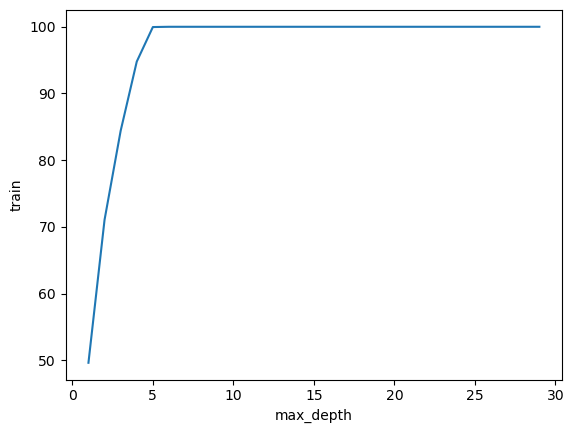

In [11]:
sns.lineplot(x='max_depth', y='train', data=result_main['result'])
# En el siguiente cuadro se presenta un gráfico que muestra, en un lado, nuestros datos de entrenamiento (train), y en el eje x, la variable 'max_depth'.

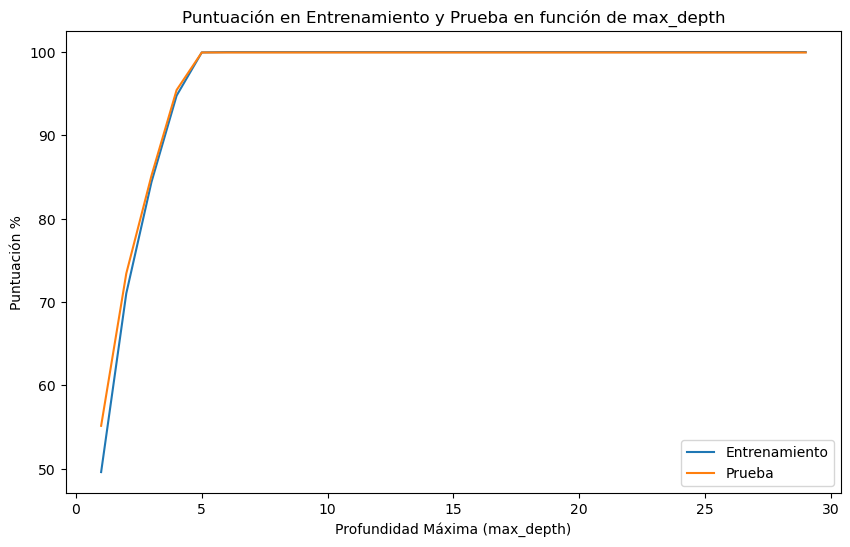

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='max_depth', y='train', data=result_main['result'], label='Entrenamiento')
sns.lineplot(x='max_depth', y='test', data=result_main['result'], label='Prueba')
plt.xlabel('Profundidad Máxima (max_depth)')
plt.ylabel('Puntuación %')
plt.title('Puntuación en Entrenamiento y Prueba en función de max_depth')

plt.legend()
plt.show()

In [13]:
result_main['result'].sort_values('test', ascending=False).head()

,max_depth,train,test
14,15,100.0,99.95
15,16,100.0,99.95
27,28,100.0,99.95
26,27,100.0,99.95
25,26,100.0,99.95


# 7. A continuación, continuamos explorando parámetros para la optimización de nuestro código. En esta ocasión, añadiremos 'min_samples_leaf' como un parámetro a nuestro DecisionTreeClassifier.
* min_samples_leaf: Cantidad mínima de muestras requeridas en las hojas de nuestro árbol.

In [14]:
def train_decision_tree(max_depth, min_samples_leaf, x_asc, y_asc, data):
    SEED = 301
    np.random.seed(SEED)

    cv = GroupKFold(n_splits=8)
    modelo = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    train_score = results['train_score'].mean() * 100
    test_score = results['test_score'].mean() * 100
    
    print('Arbol max_depth = %d, min_samples_leaf = %d, training = %.2f, testing = %.2f' % (max_depth, min_samples_leaf, train_score, test_score))
    tabla = [max_depth, min_samples_leaf, train_score, test_score]
    return tabla

def Search_Best_Result(x_asc, y_asc, data):
    resultados = []
    for max_depth in range(1, 33):
        for min_samples_leaf in [32, 64, 128, 256]:
            tabla = train_decision_tree(max_depth, min_samples_leaf, x_asc, y_asc, data)
            resultados.append(tabla)
            
    resultados = pd.DataFrame(resultados, columns=['max_depth', 'min_samples_leaf', 'train', 'test'])
    print(len(resultados))
    return resultados.head(50)

result1 = Search_Best_Result(x_asc, y_asc, data)
result1
# El resultado óptimo para nuestro parámetro 'max_depth' y min_samples_leaf es:  
# Arbol max_depth = 5, min_samples_leaf = 32, training = 99.96, testing = 99.95

Arbol max_depth = 1, min_samples_leaf = 32, training = 49.61, testing = 55.16
Arbol max_depth = 1, min_samples_leaf = 64, training = 49.61, testing = 55.16
Arbol max_depth = 1, min_samples_leaf = 128, training = 49.61, testing = 55.16
Arbol max_depth = 1, min_samples_leaf = 256, training = 49.61, testing = 55.16
Arbol max_depth = 2, min_samples_leaf = 32, training = 71.05, testing = 73.44
Arbol max_depth = 2, min_samples_leaf = 64, training = 71.05, testing = 73.44
Arbol max_depth = 2, min_samples_leaf = 128, training = 71.05, testing = 73.44
Arbol max_depth = 2, min_samples_leaf = 256, training = 66.64, testing = 69.76
Arbol max_depth = 3, min_samples_leaf = 32, training = 84.40, testing = 85.16
Arbol max_depth = 3, min_samples_leaf = 64, training = 84.40, testing = 85.16
Arbol max_depth = 3, min_samples_leaf = 128, training = 84.40, testing = 85.16
Arbol max_depth = 3, min_samples_leaf = 256, training = 79.99, testing = 81.48
Arbol max_depth = 4, min_samples_leaf = 32, training = 94.

,max_depth,min_samples_leaf,train,test
0,1,32,49.612151,55.155859
1,1,64,49.612151,55.155859
2,1,128,49.612151,55.155859
3,1,256,49.612151,55.155859
4,2,32,71.046324,73.439109
5,2,64,71.046324,73.439109
6,2,128,71.046324,73.439109
7,2,256,66.639856,69.759750
8,3,32,84.398515,85.161166
9,3,64,84.398515,85.161166


In [15]:
corr1 = result1.corr()
corr1

,max_depth,min_samples_leaf,train,test
max_depth,1.000000,-0.058298,0.715799,0.722098
min_samples_leaf,-0.058298,1.000000,-0.217350,-0.206673
train,0.715799,-0.217350,1.000000,0.999673
test,0.722098,-0.206673,0.999673,1.000000


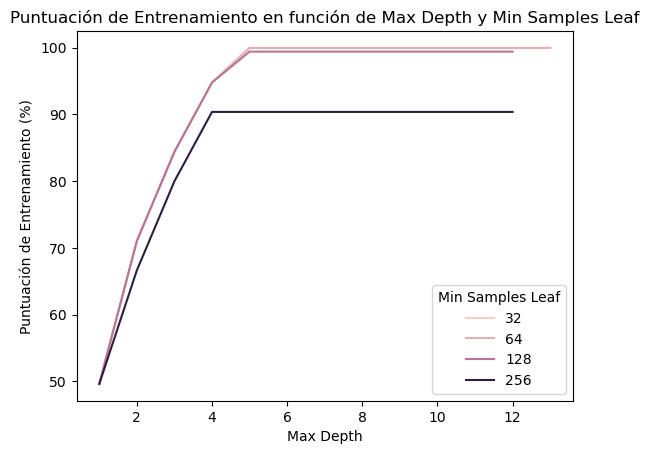

In [16]:
sns.lineplot(data=result1, x='max_depth', y='train', hue='min_samples_leaf')
#sns.lineplot(data=result1, x='max_depth', y='test', hue='min_samples_leaf')
plt.title('Puntuación de Entrenamiento en función de Max Depth y Min Samples Leaf')
plt.xlabel('Max Depth')
plt.ylabel('Puntuación de Entrenamiento (%)')
plt.legend(title='Min Samples Leaf')
plt.show()

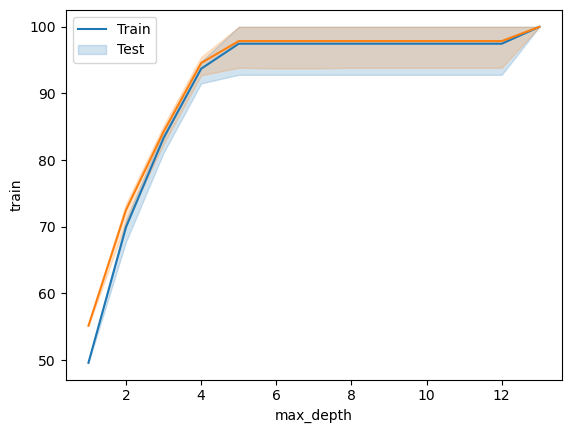

In [17]:
sns.lineplot(x='max_depth', y='train', data=result1)
sns.lineplot(x='max_depth', y='test', data=result1)
plt.legend(['Train','Test'])

# 8. Explorando 3 dimensiones de hiper parámetros

In [18]:
def train_decision_tree(max_depth, min_samples_leaf, min_samples_split, x_asc, y_asc, data):
    cv = GroupKFold(n_splits=8)
    modelo = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, min_samples_split=min_samples_split)
    results = cross_validate(modelo, x_asc, y_asc, cv=cv, groups=data.STATE_PH_INT, return_train_score=True)
    
    fit_time    = results['fit_time'].mean()
    score_time  = results['score_time'].mean()
    train_score = results['train_score'].mean() * 100
    test_score  = results['test_score'].mean() * 100
    
    print(max_depth+1,'Arbol max_depth = %d, min_samples_leaf = %d, min_samples_split = %d, training = %.2f, testing = %.2f' % (max_depth, min_samples_leaf, min_samples_split, train_score, test_score))

    tabla = [max_depth, min_samples_leaf, min_samples_split, train_score, test_score, fit_time, score_time]
    return tabla

def Search_Best_Result(x_asc, y_asc, data):
    resultados = []
    max_depth_values = list(range(1, 33))
    min_samples_leaf_values = [32, 64, 128, 256]
    min_samples_split_values = [32, 64, 128, 256]

    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:
            for min_samples_split in min_samples_split_values:
                tabla = train_decision_tree(max_depth, min_samples_leaf, min_samples_split, x_asc, y_asc, data)
                resultados.append(tabla)

    resultados_df = pd.DataFrame(resultados, columns=['max_depth', 'min_samples_leaf', 'min_samples_split', 'train', 'test', 'fit_time', 'score_time'])
    return resultados_df

x_asc = np.array(x_asc)
y_asc = np.array(y_asc)

result2 = Search_Best_Result(np.array(x_asc), np.array(y_asc), data)
result2.head(50)

     #"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    # resultados más óptimo que se ajusta a los parámetros ideales para nuestro modelo incluye:
   # max_depth configurado en 5.
  # min_samples_leaf establecido en 128.
 # min_samples_split ajustado a 32.
#------------------------------------------------------------------------------------------------


2 Arbol max_depth = 1, min_samples_leaf = 32, min_samples_split = 32, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 32, min_samples_split = 64, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 32, min_samples_split = 128, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 32, min_samples_split = 256, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 64, min_samples_split = 32, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 64, min_samples_split = 64, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 64, min_samples_split = 128, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 64, min_samples_split = 256, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 128, min_samples_split = 32, training = 49.61, testing = 55.16
2 Arbol max_depth = 1, min_samples_leaf = 128, min_samples_

'\nResultado mas optimo que se ajusta a los resultados mas optimos para nuestro modelo con el uso de parametros\n1- max_depth:5\n2- min_samples_leaf:128\n3- min_samples_split:32\n\n'

In [19]:
corr2 = result2.corr()
corr2

,max_depth,min_samples_leaf,min_samples_split,train,test,fit_time,score_time
max_depth,1.000000e+00,1.300685e-16,4.182375e-16,4.482362e-01,4.548253e-01,0.093613,-0.054940
min_samples_leaf,1.300685e-16,1.000000e+00,0.000000e+00,-3.365878e-01,-3.198302e-01,-0.040642,0.010990
min_samples_split,4.182375e-16,0.000000e+00,1.000000e+00,-2.339620e-17,-3.387889e-17,0.034976,0.020135
train,4.482362e-01,-3.365878e-01,-2.339620e-17,1.000000e+00,9.996207e-01,0.333161,0.009411
test,4.548253e-01,-3.198302e-01,-3.387889e-17,9.996207e-01,1.000000e+00,0.334401,0.010682
fit_time,9.361312e-02,-4.064200e-02,3.497639e-02,3.331608e-01,3.344012e-01,1.000000,0.262763
score_time,-5.493980e-02,1.099023e-02,2.013468e-02,9.410759e-03,1.068193e-02,0.262763,1.000000


In [20]:
result2.sort_values('test', ascending = False).head()

,max_depth,min_samples_leaf,min_samples_split,train,test,fit_time,score_time
256,17,32,32,99.96164,99.954212,0.001505,0.000495
209,14,32,64,99.96164,99.954212,0.001742,0.000500
215,14,64,256,99.96164,99.954212,0.001867,0.000373
214,14,64,128,99.96164,99.954212,0.001880,0.000379
213,14,64,64,99.96164,99.954212,0.001624,0.000125


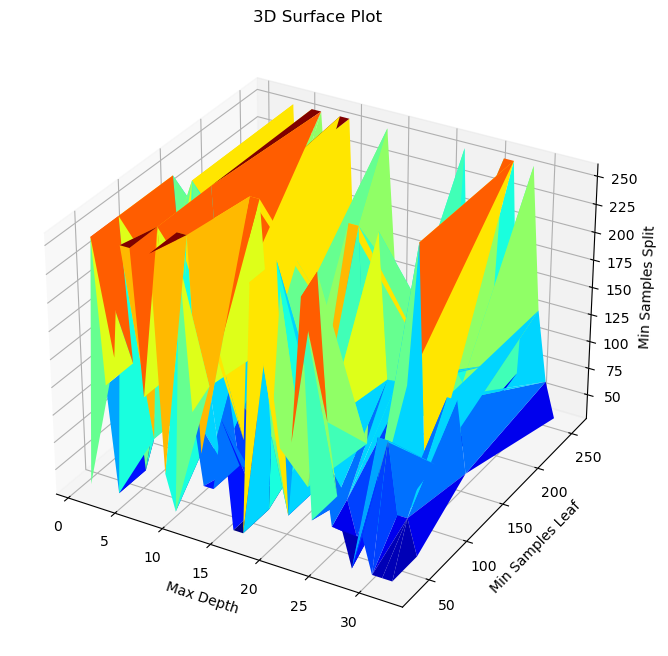

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_surface(df, x, y, z, xlabel, ylabel, zlabel, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    x_values = df[x]
    y_values = df[y]
    z_values = df[z]
    
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='viridis')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='coolwarm')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='plasma')
    #ax.plot_trisurf(x_values, y_values, z_values, cmap='inferno')
    ax.plot_trisurf(x_values, y_values, z_values, cmap='jet')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)
    ax.set_title(title)
    
    plt.show()

plot_3d_surface(result2, 'max_depth', 'min_samples_leaf', 'min_samples_split', 'Max Depth', 'Min Samples Leaf', 'Min Samples Split', '3D Surface Plot') 

#### El resultado será un gráfico tridimensional en el que cada punto en el espacio 3D se representa por los valores de 'max_depth', 'min_samples_leaf' y 'min_samples_split', y el color de cada punto se determina por el valor de 'min_samples_split'. Este tipo de gráfico se utiliza para visualizar relaciones entre tres variables en un espacio 3D y es útil para identificar patrones o tendencias en los datos.

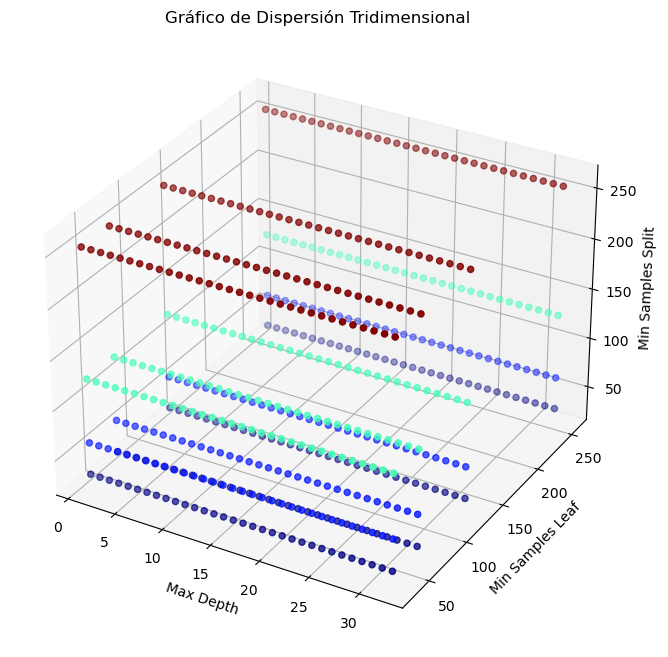

In [22]:
x = result2['max_depth']
y = result2['min_samples_leaf']
z = result2['min_samples_split']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c=z, cmap='jet')

# Etiquetas de los ejes y título
ax.set_xlabel('Max Depth')
ax.set_ylabel('Min Samples Leaf')
ax.set_zlabel('Min Samples Split')
ax.set_title('Gráfico de Dispersión Tridimensional')

plt.show()


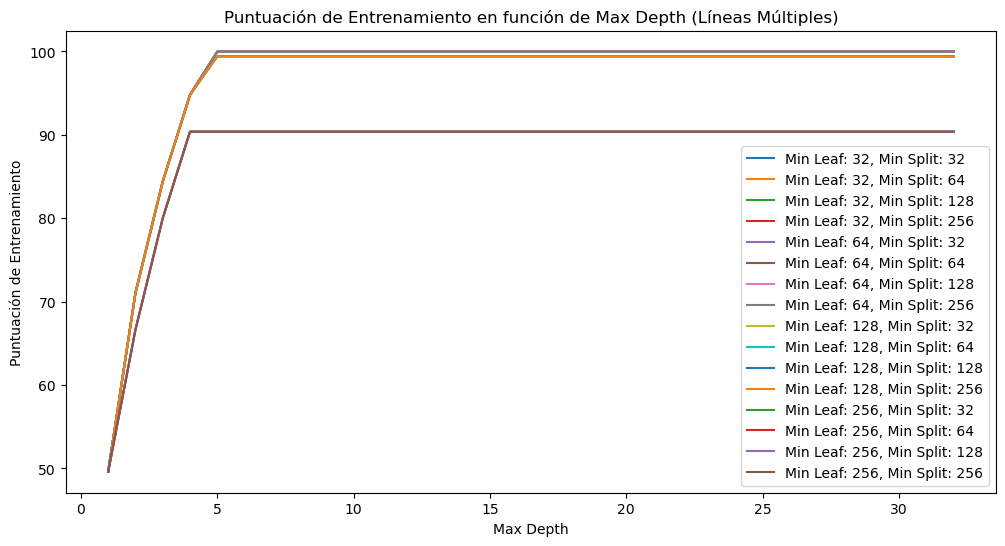

In [23]:
# max_depth_values = list(range(1, 33))
# min_samples_leaf_values = [32, 64, 128, 256]
# min_samples_split_values = [32, 64, 128, 256]

plt.figure(figsize=(12, 6))

max_depth_values = list(range(1, 33))
for min_samples_leaf in [32, 64, 128, 256]:
    for min_samples_split in [32, 64, 128, 256]:
        df_subset = result2[(result2['min_samples_leaf'] == min_samples_leaf) & (result2['min_samples_split'] == min_samples_split)]
        plt.plot(max_depth_values, df_subset['train'], label=f'Min Leaf: {min_samples_leaf}, Min Split: {min_samples_split}')

plt.title('Puntuación de Entrenamiento en función de Max Depth (Líneas Múltiples)')
plt.xlabel('Max Depth')
plt.ylabel('Puntuación de Entrenamiento')
plt.legend()
plt.show()


# 9. Explorando 4 dimensiones de hiperparámetros utilizando GridSearchCV
* max_depth> Profundidad máxima del árbol
* min_samples_leaf> Número mínimo de muestras en una hoja
* min_samples_split> Número mínimo de muestras requeridas para dividir un nodo

In [24]:
SEED = 301
np.random.seed(SEED)

espacio_de_parametros = {
    'max_depth' : [3,5],
    'min_samples_split' : [32,64,128],
    'min_samples_leaf' : [32,64,128],
    'criterion' : ['gini', 'entropy']
}

search_end = GridSearchCV(DecisionTreeClassifier(),
                      espacio_de_parametros,
                      cv = KFold(n_splits = 5, shuffle=True))

search_end.fit(x_asc, y_asc)
resultados = pd.DataFrame(search_end.cv_results_)
resultados.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003606,0.002726,0.000399,0.000489,gini,3,32,32,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,28
1,0.001603,0.000492,0.001200,0.000981,gini,3,32,64,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,28
2,0.001800,0.000749,0.000609,0.001218,gini,3,32,128,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,28
3,0.001998,0.000644,0.000000,0.000000,gini,3,64,32,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,28
4,0.001401,0.000490,0.000600,0.000490,gini,3,64,64,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.862004,0.84121,0.846881,0.829868,0.842803,0.844553,0.010391,28


In [25]:
scores = cross_val_score(search_end, x_asc, y_asc, cv = KFold(n_splits=5, shuffle=True))
scores

array([1.        , 0.99810964, 0.99621928, 1.        , 1.        ])

In [26]:
mejor_estimator = search_end.best_estimator_
def print_score(scores):
  media = scores.mean() * 100
  desviacion = scores.std() * 100
  print("Accuracy media %.2f" % media)
  print("Intervalo [%.2f, %.2f]" % (media - 2 * desviacion, media + 2 * desviacion))
  print(search_end.best_params_)
  print(mejor_estimator)
  print(round(search_end.best_score_ * 100,2))
    
print_score(scores) 

Accuracy media 99.89
Intervalo [99.58, 100.19]
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 32, 'min_samples_split': 32}
DecisionTreeClassifier(max_depth=5, min_samples_leaf=32, min_samples_split=32)
99.96


In [27]:
prediccion = mejor_estimator.predict(x_asc)
accuracy = accuracy_score(prediccion, y_asc) * 100
print('Accuracy para los datos fue %.2f%% ' % accuracy)

Accuracy para los datos fue 99.96% 


# 10. Codigo final de nuestro modelo DecisionTreeClassifier

In [28]:
x_train_,x_test_,y_train_,y_test_=train_test_split(x_asc,y_asc,test_size=0.25,random_state=301)

best_params={
    'max_depth':5,
    'min_samples_split':32,
    'min_samples_leaf':32,
    'criterion':'gini'
}    

modelo=DecisionTreeClassifier(**best_params)
modelo.fit(x_test_,y_test_)

y_predict=modelo.predict(x_test_)
accuracy_m=modelo.score(x_test_,y_test_)

print(f"Exactitud en datos de prueba con modelo.score {round(accuracy_m*100,2)} %")

Exactitud en datos de prueba con modelo.score 99.24 %


### A continuación, evaluaremos nuestro modelo utilizando las siguientes métricas de clasificación: accuracy_score, precisión, recall y F1-Score. El objetivo es determinar el nivel de precisión de los resultados obtenidos por nuestro modelo entrenado y optimizado con los parámetros evaluados durante el entrenamiento.

 * accuracy_score: Muestra el puntaje de rendimiento del modelo de predicción, en este caso del modelo de DecisionTreeClassifier. En donde calcula 
   Los números de predicciones correctas / número total de predicciones. Con el objetivo de realizar una evaluación detallada de modelo midiendo el nivel de puntaje obtenido. 
 * Precision: Se calcula la precisión del modelo en ese caso de DecisionTreeClassifier. En donde la relación está en el número de verdaderos positivos vs el número de falsos poistivos. tp / (tp + fp)tpfp
 * Recall: Con esto medimos los verdaderos positivos con respecto al numero total de verdades positivos y falsos negativos. Recall= TP/TP+FN
 * F1-Score: Esto realiza una combinacion de las metricas de precision y el recall. con el fin de obtener valores mas objetivo. F1 = 2 * ((recall * precision)/(recall + precision))

In [29]:
accuracy_score_end = accuracy_score(y_test_, y_predict)
precision = precision_score(y_test_, y_predict,average='macro')
recall = recall_score(y_test_, y_predict,average='macro')
f1 = f1_score(y_test_, y_predict,average='macro')

print(f"Exactitud en datos de prueba con accuracy_score: {round(accuracy_score_end * 100, 2)} %")
print(f'Accuracy: {round(accuracy_score_end*100,2)}')
print(f'Precision: {round(precision*100,2)}')
print(f'Recall: {round(recall*100,2)}')
print(f'F1-Score: {round(f1*100,2)}')

Exactitud en datos de prueba con accuracy_score: 99.24 %
Accuracy: 99.24
Precision: 97.77
Recall: 98.87
F1-Score: 98.2


 #### Resultado finl de evaluación de nuestro modelo en base a las métricas mencionadas en un dataFrame

In [3]:
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [round(accuracy_score_end*100,2), round(precision*100,2), round(recall*100,2), round(f1*100,2)]
})

results_df

NameError: name 'pd' is not defined

# 11. Realizando pruebas finales 

In [33]:
x_data = [[3.0],[8.0],[0.9]]  # Datos para la predicción
y_predd = modelo.predict(x_data)

dt_stateString = pd.DataFrame(datos_asc)
pH_group_by = dt_stateString.groupby(['STATE_PH', 'STATE_PH_INT'])

for (ph, state_ph_int), group_data in pH_group_by:
    for pred in y_predd:
        if pred==state_ph_int:
             print(f"predicción: {ph} estado {state_ph_int}")

predicción: Extremadamente Ácido estado 1
predicción: Extremadamente Ácido estado 1
predicción: Levemenete Alcalino estado 6


In [32]:
#import joblib  